In [13]:
from pathlib import Path

from eeg_music.bcmi import BCMICalibrationLoader, BCMITrainingLoader
from eeg_music.data import EEGMusicDataset
from eeg_music.data import copy_from_dataloader_into_dir
import tempfile
import matplotlib.pyplot as plt
from eeg_music.data import MappedDataset, MelParams, prepare_trial, rereference_trial, trial_to_arrayeeg
from fractions import Fraction
from eeg_music.data import StratifiedSamplingDataset
from eeg_music.onset_conversion import trial_wavraw_to_noteonsets
from eeg_music.eegpt import USING_CHANNELS

# # %load_ext autoreload
# %autoreload 2

In [14]:
def create_combined_training_calibration_dataset(
  bcmi_root_path: str, new_dataset_save_dir: Path, only_training=False
) -> EEGMusicDataset:
  """Create an EEGMusicDataset that combines BCMI training and calibration data."""

  training_loader = BCMITrainingLoader(f"{bcmi_root_path}/bcmi-training", dataset_name="bcmi-training")
  training_loader.load_all_subjects()
  copy_from_dataloader_into_dir(training_loader, new_dataset_save_dir)
  del training_loader
  if not only_training:
    calibration_loader = BCMICalibrationLoader(f"{bcmi_root_path}/bcmi-calibration", dataset_name="bcmi-calibration")
    calibration_loader.load_all_subjects()
    copy_from_dataloader_into_dir(calibration_loader, new_dataset_save_dir)
    del calibration_loader

  combined_dataset = EEGMusicDataset.load_ondisk(new_dataset_save_dir)

  return combined_dataset

In [15]:
# Created with tempfile; persists until you delete it (or OS temp cleanup).
temp_save_dir = Path(tempfile.mkdtemp(prefix="bcmi_combined_dataset_"))
combined_dataset = create_combined_training_calibration_dataset("./datasets/bcmi", temp_save_dir)

Loading subject 08 (bcmi-training):
  ✓ Run 1 ses-3: 1008.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1005.0s, 36 events, 36 trials
  ✓ Run 3 ses-3: 1010.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1011.0s, 36 events, 36 trials
Loading subject 09 (bcmi-training):
  ✓ Run 1 ses-3: 1038.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1052.0s, 36 events, 36 trials
  ✓ Run 3 ses-3: 1034.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1036.0s, 36 events, 36 trials
  ✓ Run 1 ses-1: 1045.0s, 36 events, 36 trials
  ✓ Run 2 ses-1: 1033.0s, 36 events, 36 trials
  ✓ Run 3 ses-1: 1034.0s, 36 events, 36 trials
  ✓ Run 4 ses-1: 1031.0s, 36 events, 36 trials
  ✓ Run 1 ses-2: 1036.0s, 36 events, 36 trials
  ✓ Run 2 ses-2: 1032.0s, 36 events, 36 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the h

  ✓ Run 3 ses-2: 1016.0s, 36 events, 36 trials
  ✓ Run 4 ses-2: 1026.0s, 36 events, 36 trials
Loading subject 10 (bcmi-training):
  ✓ Run 1 ses-3: 1095.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1115.0s, 36 events, 36 trials
  ✓ Run 3 ses-3: 1151.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1068.0s, 36 events, 36 trials
  ✓ Run 1 ses-1: 1130.0s, 36 events, 36 trials
  ✓ Run 2 ses-1: 1108.0s, 36 events, 36 trials
  ✓ Run 3 ses-1: 1134.0s, 36 events, 36 trials
  ✓ Run 4 ses-1: 1069.0s, 36 events, 36 trials
  ✓ Run 1 ses-2: 1112.0s, 36 events, 36 trials
  ✓ Run 2 ses-2: 1128.0s, 36 events, 36 trials
  ✓ Run 3 ses-2: 1105.0s, 36 events, 36 trials
  ✓ Run 4 ses-2: 1053.0s, 36 events, 36 trials
Loading subject 11 (bcmi-training):
  ✓ Run 1 ses-3: 1089.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1131.0s, 36 events, 36 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the h

  ✓ Run 3 ses-3: 1122.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1080.0s, 36 events, 36 trials
  ✓ Run 1 ses-1: 1245.0s, 36 events, 36 trials
  ✓ Run 2 ses-1: 1226.0s, 36 events, 36 trials
  ✓ Run 3 ses-1: 1188.0s, 36 events, 36 trials
  ✓ Run 4 ses-1: 1148.0s, 36 events, 36 trials
  ✓ Run 1 ses-2: 1169.0s, 36 events, 36 trials
  ✓ Run 2 ses-2: 1162.0s, 36 events, 36 trials
  ✓ Run 3 ses-2: 1111.0s, 36 events, 36 trials
  ✓ Run 4 ses-2: 1136.0s, 36 events, 36 trials
Loading subject 12 (bcmi-training):
  ✓ Run 1 ses-3: 1052.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1035.0s, 36 events, 36 trials
  ✓ Run 3 ses-3: 1065.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1044.0s, 36 events, 36 trials
  ✓ Run 1 ses-1: 1089.0s, 36 events, 36 trials


...

  ✓ Run 2: 875.0s, 36 events, 18 trials
  ✓ Run 3: 868.0s, 36 events, 18 trials
  ✓ Run 4: 843.0s, 36 events, 18 trials
  ✓ Run 5: 845.0s, 36 events, 18 trials
Loading subject 16 (bcmi-calibration):
  ✓ Run 1: 927.0s, 36 events, 18 trials
  ✓ Run 2: 868.0s, 36 events, 18 trials
  ✓ Run 3: 852.0s, 36 events, 18 trials
  ✓ Run 4: 823.0s, 36 events, 18 trials
  ✓ Run 5: 836.0s, 36 events, 18 trials
Loading subject 17 (bcmi-calibration):
  ✓ Run 1: 954.0s, 36 events, 18 trials
  ✓ Run 2: 829.0s, 36 events, 18 trials
  ✓ Run 3: 861.0s, 36 events, 18 trials
  ✓ Run 4: 840.0s, 36 events, 18 trials
  ✓ Run 5: 830.0s, 36 events, 18 trials
Loading subject 18 (bcmi-calibration):
  ✓ Run 1: 961.0s, 36 events, 18 trials
  ✓ Run 2: 895.0s, 36 events, 18 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the h

  ✓ Run 3: 847.0s, 36 events, 18 trials
  ✓ Run 4: 847.0s, 36 events, 18 trials
  ✓ Run 5: 830.0s, 36 events, 18 trials
Loading subject 19 (bcmi-calibration):
  ✓ Run 1: 960.0s, 36 events, 18 trials
  ✓ Run 2: 964.0s, 36 events, 18 trials
  ✓ Run 3: 869.0s, 36 events, 18 trials
  ✓ Run 4: 856.0s, 36 events, 18 trials
  ✓ Run 5: 853.0s, 36 events, 18 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type

Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 

In [5]:
from eeg_music.bcmi import BCMIScoresLoader

def create_scores_dataset(
  bcmi_root_path: str, new_dataset_save_dir: Path, only_training=False
) -> EEGMusicDataset:
  """Create an EEGMusicDataset that combines BCMI scores data."""

  training_loader = BCMIScoresLoader(f"{bcmi_root_path}/bcmi-scores", dataset_name="bcmi-scores")
  training_loader.load_all_subjects()
  copy_from_dataloader_into_dir(training_loader, new_dataset_save_dir)

  combined_dataset = EEGMusicDataset.load_ondisk(new_dataset_save_dir)

  return combined_dataset

In [6]:
from eeg_music.data import EEGMusicDataset

temp_save_dir = Path(tempfile.mkdtemp(prefix="bcmi_scores_dataset_"))
scores = create_scores_dataset("./datasets/bcmi", temp_save_dir)

Loading subject 01 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 574.0s, 715 events, 0 trials
  ✓ Run 3: 552.0s, 740 events, 0 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 17 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 41 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeW

  ✓ Run 4: 518.0s, 739 events, 0 trials
  ✓ Run 5: 539.0s, 743 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 02 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 568.0s, 791 events, 0 trials
  ✓ Run 3: 516.0s, 758 events, 0 trials
  ✓ Run 4: 510.0s, 763 events, 0 trials
  ✓ Run 5: 486.0s, 732 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 03 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 698.0s, 736 events, 0 trials
  ✓ Run 3: 635.0s, 750 events, 0 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 54 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Omitted 2

  ✓ Run 4: 602.0s, 739 events, 0 trials
  ✓ Run 5: 596.0s, 746 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 04 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 719.0s, 684 events, 0 trials
  ✓ Run 3: 610.0s, 680 events, 0 trials
  ✓ Run 4: 588.0s, 686 events, 0 trials
  ✓ Run 5: 553.0s, 681 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 05 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 678.0s, 700 events, 0 trials
  ✓ Run 3: 612.0s, 693 events, 0 trials


...

  ✓ Run 5: 542.0s, 690 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 28 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 590.0s, 819 events, 0 trials
  ✓ Run 3: 551.0s, 815 events, 0 trials
  ✓ Run 4: 549.0s, 800 events, 0 trials
  ✓ Run 5: 520.0s, 796 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 29 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 25 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 33 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeW

  ✓ Run 2: 621.0s, 744 events, 0 trials
  ✓ Run 3: 656.0s, 726 events, 0 trials
  ✓ Run 4: 659.0s, 716 events, 0 trials
  ✓ Run 5: 595.0s, 710 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 30 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 694.0s, 695 events, 0 trials
  ✓ Run 3: 663.0s, 694 events, 0 trials
  ✓ Run 4: 599.0s, 701 events, 0 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 33 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Limited 33 annotation(s) that were expanding outside the data range.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeW

  ✓ Run 5: 590.0s, 706 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Loading subject 31 (bcmi-scores):
  ✓ Run 1: 304.0s, 1 events, 1 trials
  ✓ Run 2: 676.0s, 706 events, 0 trials
  ✓ Run 3: 560.0s, 713 events, 0 trials
  ✓ Run 4: 531.0s, 704 events, 0 trials
  ✓ Run 5: 546.0s, 706 events, 0 trials
  ✓ Run 6: 304.0s, 1 events, 1 trials
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ...    19.999 secs...
Reading 0 ... 19999  =      0.000 ..

In [ ]:
# mapped.save(Path("./datasets/bcmi_preprocessed/bcmi_combined_processed_28ch"))

In [ ]:
# this is loaded

def load(ds_path):
  return EEGMusicDataset.load_ondisk(ds_path)

# ds.subject_wise_split(ptrain, pval, seed)

def after_loaded_ds(ds, trial_length_secs=Fraction(4,1)):
  stratified = StratifiedSamplingDataset(
    ds,
    n_strata=10,
    trial_length_secs=trial_length_secs,
  )

  dereferenced = MappedDataset(
    stratified,
    rereference_trial
  )

  return dereferenced


In [ ]:
# one_ds = load(Path("./datasets/bcmi_preprocessed/onesubject_bcmi_combined_noteonsets_28ch"))

In [26]:
combined_dataset.df

dataset subject  \
dataset          subject session    run trial_id                             
bcmi-training    08      3          1   trial_1      bcmi-training      08   
                                        trial_2      bcmi-training      08   
                                        trial_3      bcmi-training      08   
                                        trial_4      bcmi-training      08   
                                        trial_5      bcmi-training      08   
...                                                            ...     ...   
bcmi-calibration 19      no_session 5   trial_14  bcmi-calibration      19   
                                        trial_15  bcmi-calibration      19   
                                        trial_16  bcmi-calibration      19   
                                        trial_17  bcmi-calibration      19   
                                        trial_18  bcmi-calibration      19   

                                                     session run  trial_id  \
dataset          subject session    run trial_id                             
bcmi-training    08      3          1   trial_1            3   1   trial_1   
                                        trial_2            3   1   trial_2   
                                        trial_3            3   1   trial_3   
                                        trial_4            3   1   trial_4   
                                        trial_5            3   1   trial_5   
...                                                      ...  ..       ...   
bcmi-calibration 19      no_session 5   trial_14  no_session   5  trial_14   
                                        trial_15  no_session   5  trial_15   
                                        trial_16  no_session   5  trial_16   
                                        trial_17  no_session   5  trial_17   
                                        trial_18  no_session   5  trial_18   

                                                                              music_filename  \
dataset          subject session    run trial_id                                               
bcmi-training    08      3          1   trial_1    MusicFilename(filename='1-6_3_first.wav')   
                                        trial_2   MusicFilename(filename='1-6_3_second.wav')   
                                        trial_3    MusicFilename(filename='9-6_3_first.wav')   
                                        trial_4   MusicFilename(filename='9-6_3_second.wav')   
                                        trial_5    MusicFilename(filename='9-3_3_first.wav')   
...                                                                                      ...   
bcmi-calibration 19      no_session 5   trial_14         MusicFilename(filename='nvla5.wav')   
                                        trial_15         MusicFilename(filename='nvha2.wav')   
                                        trial_16         MusicFilename(filename='nvla6.wav')   
                                        trial_17        MusicFilename(filename='lvha11.wav')   
                                        trial_18         MusicFilename(filename='hvna6.wav')   

                                                                                           eeg_data  
dataset          subject session    run trial_id                                                     
bcmi-training    08      3          1   trial_1   OnDiskEeg(filepath=PosixPath('/tmp/bcmi_combin...  
                                        trial_2   OnDiskEeg(filepath=PosixPath('/tmp/bcmi_combin...  
                                        trial_3   OnDiskEeg(filepath=PosixPath('/tmp/bcmi_combin...  
                                        trial_4   OnDiskEeg(filepath=PosixPath('/tmp/bcmi_combin...  
                                        trial_5   OnDiskEeg(filepath=PosixPath('/tmp/bcmi_combin...  
...                                                               

In [ ]:
# filtered_ds = EEGMusicDataset()
# filtered_ds.df = combined_dataset.df.sample(n=150, random_state=420).reset_index(drop=True)
# filtered_ds.music_collection = combined_dataset.music_collection

In [34]:
combined_dataset.df.groupby(['dataset', 'subject']).size().sort_values(ascending=False)

ValueError: 'dataset' is both an index level and a column label, which is ambiguous.

In [ ]:
filtered_ds = EEGMusicDataset()
filtered_ds.df = combincombined_dataseted_dataset.df.loc[(combined_dataset.df.dataset == "bcmi-training") & (combined_dataset.df.subject == "08")].reset_index(drop=True)
filtered_ds.music_collection = combined_dataset.music_collection
len(filtered_ds)

144

In [43]:
from eeg_music.band_power import trial_to_band_power, BandPowerParams
from eeg_music.data import RobustNormalizedDataset

one_sec_ds = MappedDataset(
  filtered_ds,
  lambda t:
      # trial_to_arrayeeg(
        # rereference_trial(
          # trial_wavraw_to_noteonsets(
            prepare_trial(
              t,
            eeg_resample=None,
            eeg_l_freq=1.0,
            eeg_h_freq=64.0,
            # eeg_h_freq=128.0,
            max_len=4.0,
          ) # type: ignore
        # )
      # )
    # )
)

# one_sec_ds = RobustNormalizedDataset(one_sec_ds)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 3301 samples (3.301 s)



TrialPlots(eeg_plot=<MNEBrowseFigure size 800x800 with 4 Axes>, spectrogram_plot=<Figure size 800x300 with 2 Axes>, metadata={'dataset': 'bcmi-training', 'subject': '08', 'session': '3', 'run': '1', 'trial_id': 'trial_1', 'music_filename': '1-6_3_first.wav', 'eeg_channels': ['FP1', 'FPz', 'FP2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FT9', 'FC5', 'FC1', 'FC2', 'FC6', 'FT10', 'T7', 'C3', 'Cz', 'C4', 'T8', 'TP9', 'CP5', 'CP1', 'CP2', 'CP6', 'TP10', 'P7', 'P3', 'Pz', 'P4', 'P8', 'O1', 'O2', 'GSR', 'ECG', 'VA1', 'VA2', 'VAtarg'], 'eeg_sample_rate': 1000.0, 'eeg_duration_seconds': np.float64(3.999), 'music_sample_rate': 44100, 'music_duration_seconds': 4.0})

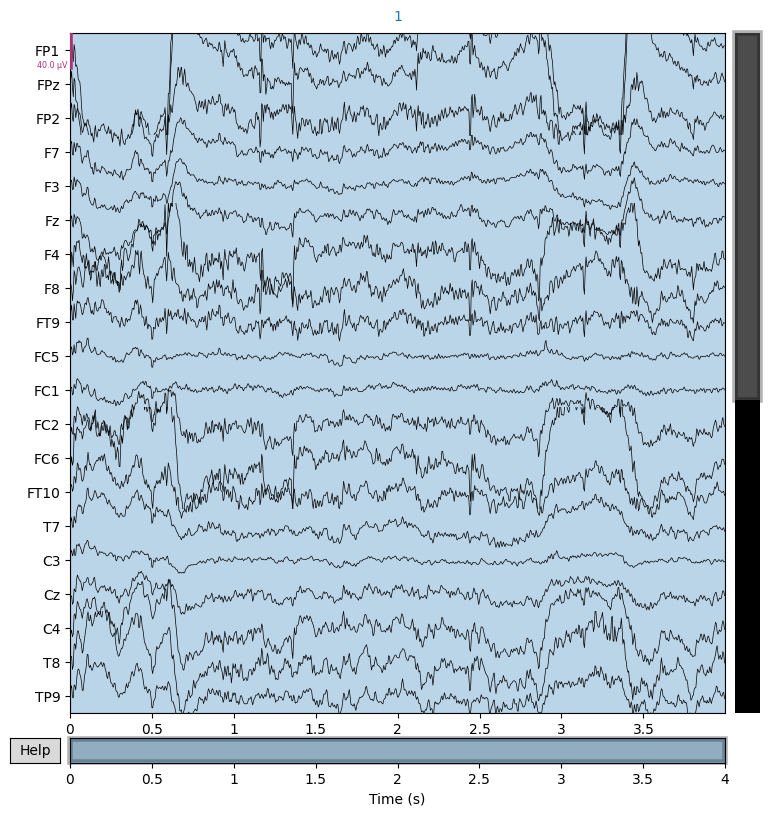

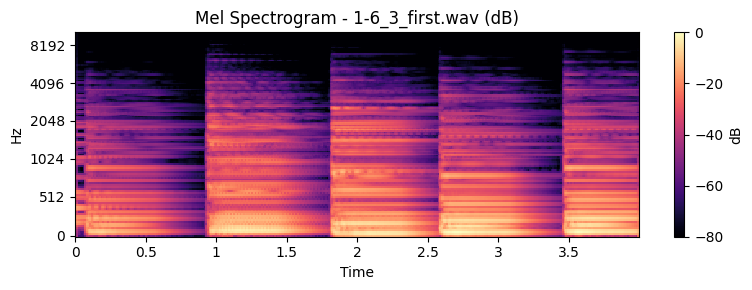

In [44]:
from eeg_music.plotting import plot_trial_data
plot_trial_data(one_sec_ds[0])

In [45]:
one_sec_ds.save(Path("./datasets/bcmi_preprocessed/onesubject_bcmi_37ch"))

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 

In [41]:
from eeg_music.band_power import trial_to_band_power, BandPowerParams
from eeg_music.data import RobustNormalizedDataset

one_sec_ds = MappedDataset(
  filtered_ds,
  lambda t:
    trial_to_band_power(BandPowerParams(
        frequency_bands=[(0.5, 4.0), (4.0, 8.0), (8.0, 13.0), (13.0, 30.0)],
        window_width=50,
        hop_length=20,
    ))(
      # trial_to_arrayeeg(
        rereference_trial(
          trial_wavraw_to_noteonsets(
            prepare_trial(
              t,
            eeg_resample=None,
            eeg_l_freq=1.0,
            eeg_h_freq=64.0,
            # eeg_h_freq=128.0,
            max_len=4.0,
          ) # type: ignore
        )
      )
    # )
  )
)

one_sec_ds = RobustNormalizedDataset(one_sec_ds)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters


---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 3301 samp

In [28]:
one_sec_ds[0]

TrialData(dataset='bcmi-calibration', subject='19', session='no_session', run='2', trial_id='trial_1', music_filename=MusicFilename(filename='lvla4.wav'), eeg_data=ArrayEeg(data=array([[-2.19103601e-03, -5.72912686e-04,  4.41137096e-03, ...,
        -1.44605655e-02, -1.50007680e-02, -1.51060950e-02],
       [-9.09991097e-04,  6.70215595e-05,  1.72102498e-03, ...,
        -1.03157177e-03, -1.28094363e-03, -1.44815212e-03],
       [ 6.92899164e-04,  1.55038782e-04, -7.47620506e-05, ...,
        -4.47853643e-04, -4.84407909e-04, -5.26836666e-04],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(148, 253), dtype=float32), ch_names=['FP1_band0', 'F

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 64.00 Hz
- Upper transition bandwidth: 16.00 Hz (-6 dB cutoff frequency: 72.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 64 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 

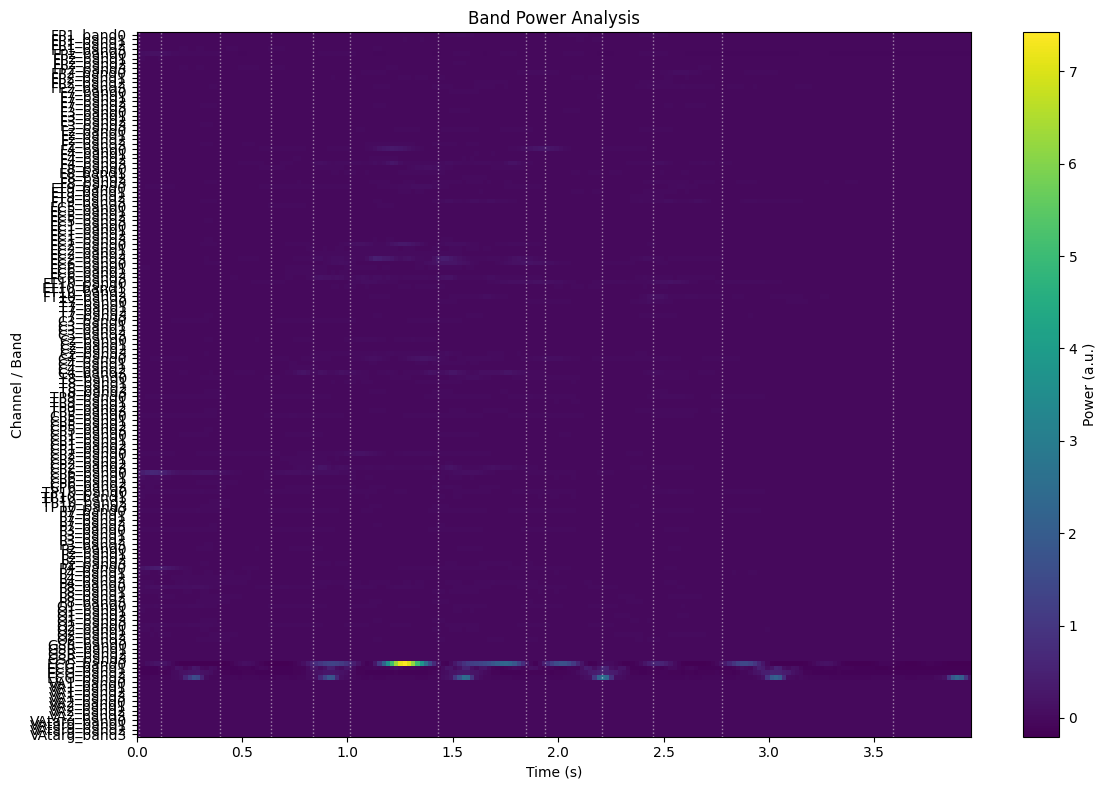

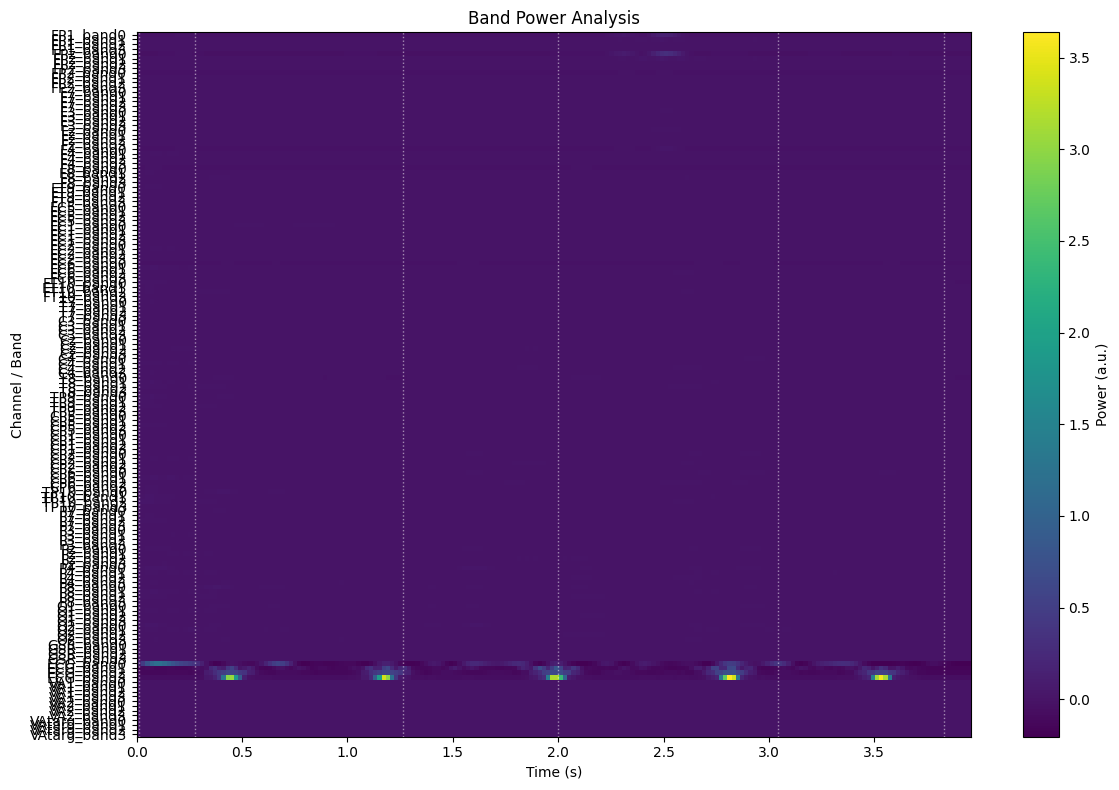

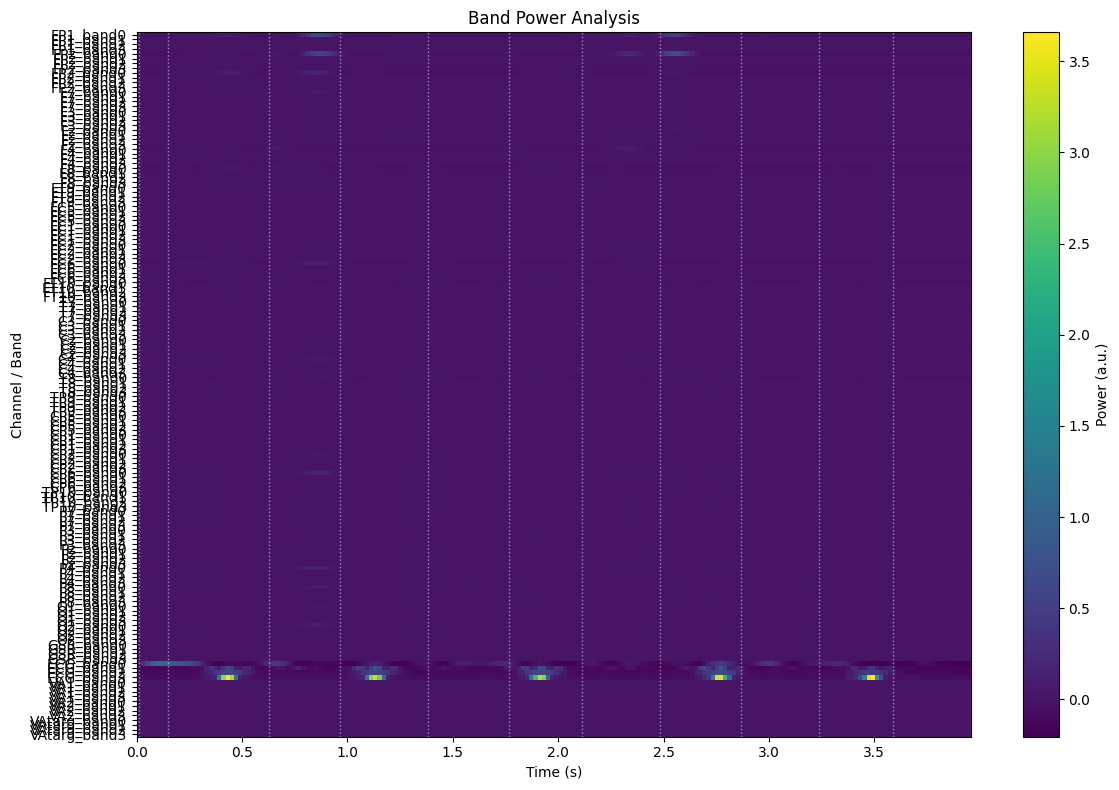

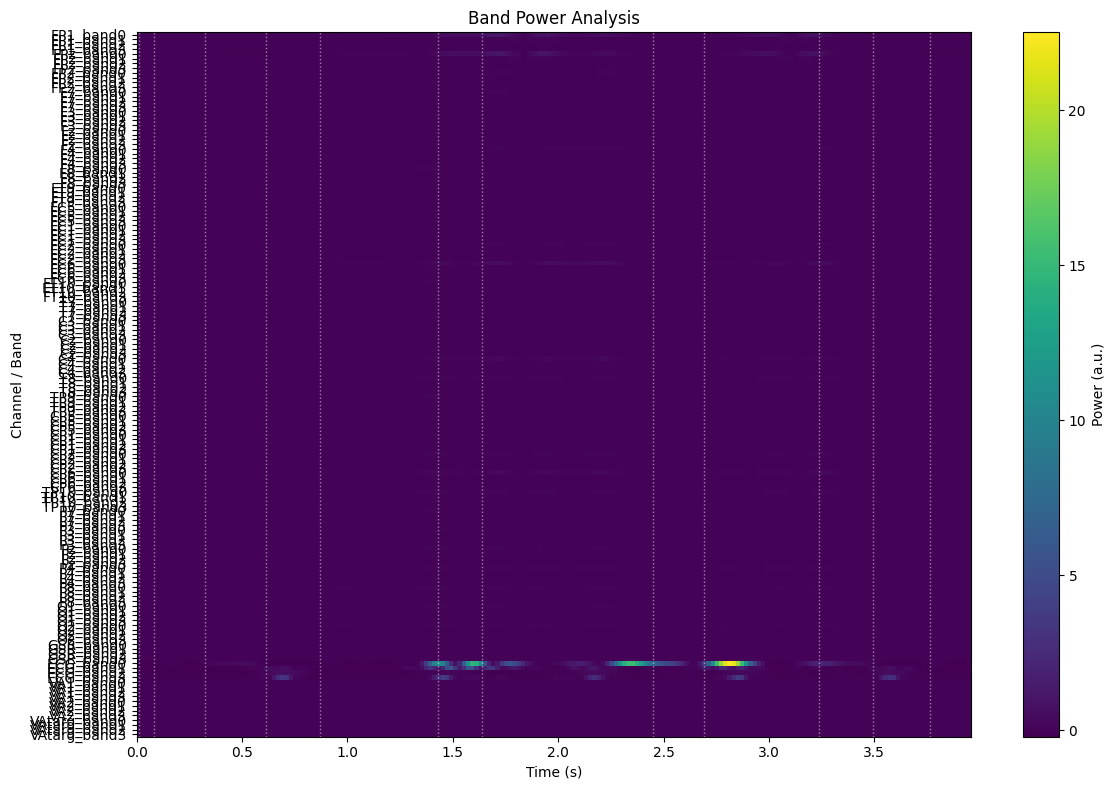

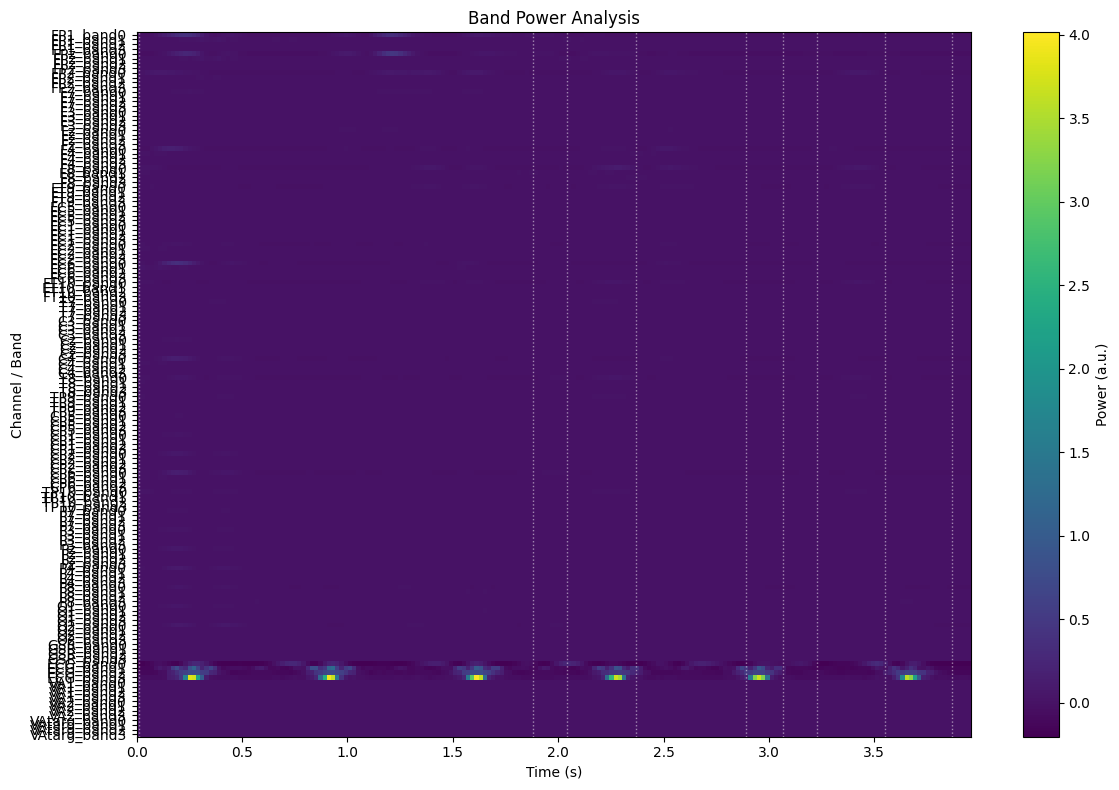

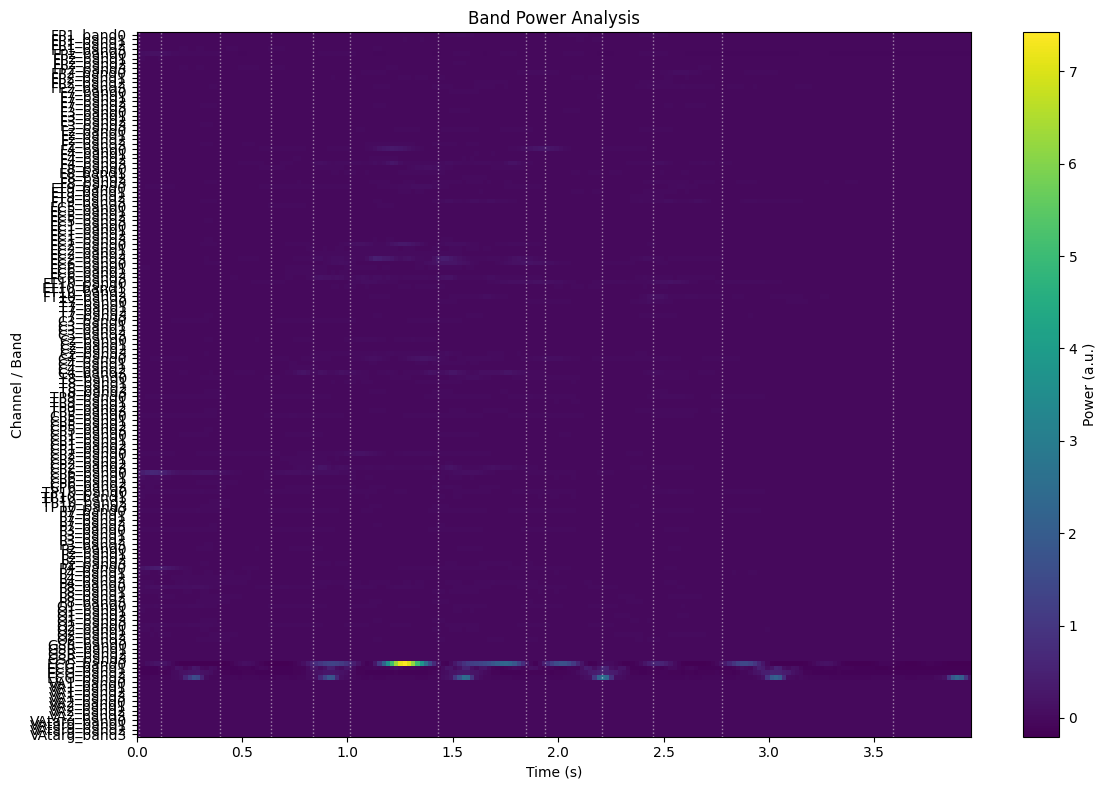

In [42]:
from eeg_music.plotting import plot_band_power_with_onsets

plot_band_power_with_onsets(one_sec_ds[6])
plot_band_power_with_onsets(one_sec_ds[1])
plot_band_power_with_onsets(one_sec_ds[2])
plot_band_power_with_onsets(one_sec_ds[16])
plot_band_power_with_onsets(one_sec_ds[60])

In [7]:
one_sec_ds.save(Path("./datasets/bcmi_preprocessed/one_sec_power_ds"))

In [ ]:
from eeg_music.data import RobustNormalizedDataset
from eeg_music.training import NoteOnsetsTrainingConfig
from eeg_music.eegnet import NoteOnsetModelConfig
from eeg_music.eegpt import UseAdamW
from eeg_music.training import TrialWiseSplit

from eeg_music.dataloader import load_and_create_dataloaders
from eeg_music.data import EEGMusicDataset
from eeg_music.dataloader import create_collate_fn
import torch

config = NoteOnsetsTrainingConfig()
config.include_info = True
config.ds_split_type = TrialWiseSplit()
config.batch_size = 16
config.model_config.eeg_sample_rate=256
config.model_config.window_start=32
config.model_config.window_end=32 + 64
config.model_config.num_channels=37
config.ds_chunk_width = Fraction(1, 1)
config.data_path = Path("./datasets/bcmi_preprocessed/one_sec_power_ds")

class MySelf:
  config: NoteOnsetsTrainingConfig

self = MySelf()
self.config = config

def create_dataloaders(self):
    # Custom dataloader implementation
    # Example: you can modify include_info, collate_fn, or other parameters
    def after_loaded_ds(data: EEGMusicDataset, trial_length_secs) -> EEGMusicDataset:
      # mapped = MappedDataset(data, rereference_trial)
      mapped = RobustNormalizedDataset(data)
      return mapped

    include_info = (
      self.config.include_info or self.config.model_config.use_subject_specific
    )
    self.dataloaders = load_and_create_dataloaders(
      self.config.data_path,
      self.config,
      collate_fn=create_collate_fn(
        include_info=include_info,
        music_batch_fn=lambda x: x,
        eeg_batch_fn=lambda x: torch.stack(
          [torch.from_numpy(a.get_array().data) for a in x]  # pyright: ignore[reportAttributeAccessIssue]
        ),
      ),
      include_mapper=self.config.model_config.use_subject_specific,
      split_type=self.config.ds_split_type,
      after_loaded_ds=after_loaded_ds,
    )
    if self.config.ds_split_type == TrialWiseSplit:
      assert self.dataloaders["num_skipped_trials"] == 0


In [ ]:
dls = create_dataloaders(self)
print(len(dls["train"]))
print(len(dls["val"]))
print(len(dls["test"]))